uv pip install langgraph

定义state
****
- TypedDict：属于Python标准库typing模块的一部分，仅提供静态类型检查，运行时不执行验证
- Pydantic： 第三方库，需单独安装，提供运行形式数据验证和序列化功能

In [3]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict

#定义节点间通讯的消息格式

class State(TypedDict):
    message: list[AnyMessage]
    extra_field: int



定义节点

In [9]:
from langchain_core.messages import  AIMessage

def node(state: State) :
    #处理输入消息
    input_message = state['message']
    #生成输出消息
    output_message = AIMessage(content="你好！这是节点的回复。")
    return {
        'message': [output_message],
        'extra_field': state['extra_field'] + 1
    }

创建图
****
- 包含一个节点
- 使用state通信


In [11]:
from langgraph.graph import StateGraph

graph=StateGraph(State)
graph.add_node(node)
graph.set_entry_point("node")
graph_builder=graph.compile()

#### 查看节点与图结构


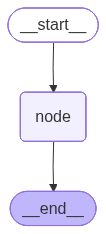

In [12]:
from IPython.display import display,Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

调用

In [13]:
from langchain_core.messages import HumanMessage

result= graph_builder.invoke({
    "message":[HumanMessage("你好。我是hakimi")],
    "extra_field": 0
})
result

{'message': [AIMessage(content='你好！这是节点的回复。', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'extra_field': 1}

使用pretty_print来格式化显示

In [14]:
from langchain_core.messages import  HumanMessage
result= graph_builder.invoke({
    "message":[HumanMessage("你好。我是hakimi")],
    "extra_field": 0
})
for message in result['message']:
    message.pretty_print()

================================== Ai Message ==================================

你好！这是节点的回复。


串行控制

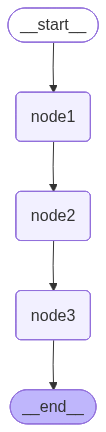

In [17]:
from typing_extensions import TypedDict
from IPython.display import display,Image
from langgraph.graph import StateGraph,START,END

class State(TypedDict):
    value_1: str
    value_2: str


def node1(state: State) :
    return {
        'value_1': "这是节点1的输出",
    }


def node2(state: State) :
    current_value_1 = state['value_1']
    return{"value_1":f"节点2接收到的输入是：{current_value_1}"}


def node3(state: State) :
    return{"value_2":"10"}


graph_builder=StateGraph(State)
graph_builder.add_node(node1)
graph_builder.add_node(node2)
graph_builder.add_node(node3)
graph_builder.add_edge(START, "node1")
graph_builder.add_edge("node1", "node2")
graph_builder.add_edge("node2", "node3")
graph_builder.add_edge("node3", END)

graph=graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
graph.invoke({"value_1": "c", "value_2": "d"})

{'value_1': '节点2接收到的输入是：这是节点1的输出', 'value_2': '10'}

分支控制
***

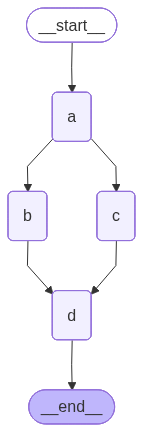

In [18]:
import operator
from langgraph.graph import StateGraph,START,END
from typing_extensions import TypedDict
from IPython.display import display,Image
from typing import Any,Annotated

#Annotated类型用于在类型提示中添加额外的元信息，这些元信息可以在运行时通过get_type_hints函数获取。它允许我们为类型提示提供更多的上下文信息，例如默认值、验证规则等。
class State(TypedDict):
    aggregate: Annotated[list, operator.add]


def a(state: State) :
    print(f"节点1接收到的输入是：{state['aggregate']}")
    return {
        "aggregate": ["A"],
    }


def b(state: State) :
    current_aggregate = state['aggregate']
    print(f"节点2接收到的输入是：{current_aggregate}")
    return{"aggregate": ["B"]}


def c(state: State):
    current_aggregate = state['aggregate']
    print(f"节点3接收到的输入是：{current_aggregate}")
    return{"aggregate": ["C"]}


def d(state: State):
    current_aggregate = state['aggregate']
    print(f"节点4接收到的输入是：{current_aggregate}")
    return{"aggregate": ["D"]}




builder=StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c) 
builder.add_node(d)
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
graph.invoke({"aggregate": []},{"configurable":{"thread_id": "1"}})


节点1接收到的输入是：[]
节点2接收到的输入是：['A']
节点3接收到的输入是：['A']
节点4接收到的输入是：['A', 'B', 'C']


{'aggregate': ['A', 'B', 'C', 'D']}

条件分支和循环（略）

图运行时的配置
***

sk-086eab12ddb74ede8b508513c8efd1f2


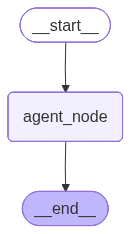

sk-086eab12ddb74ede8b508513c8efd1f2
{'agent_node': {'message': [AIMessage(content='你好！很高兴认识你！😊\n\n我是 **DeepSeek**，由深度求索公司开发的AI助手。让我简单介绍一下自己：\n\n## 🌟 我的特点\n\n- **完全免费**：没有任何收费计划，可以放心使用\n- **超大上下文**：支持1M上下文，能一次性处理像《三体》三部曲这样的长篇内容\n- **多种交互方式**：\n  - Web端和App端都可以使用\n  - 支持语音输入（App端）\n  - 支持文件上传（图像、txt、pdf、ppt、word、excel）\n- **联网搜索**：可以获取最新信息（需要手动开启）\n- **纯文本模型**：虽然不支持多模态识别，但可以从上传的图片中读取文字信息\n\n## 📅 基本信息\n\n- 知识截止日期：2025年5月\n- 版本：DeepSeek最新版模型\n- 能力：擅长回答各种问题，从日常闲聊到专业技术问题都可以\n\n## 💬 我能帮你什么？\n\n无论是学习、工作、创作还是日常生活问题，我都很乐意帮忙！你可以把我当作一个热情、细腻的朋友，我会用和你一样的语言来交流。\n\n有什么我可以帮你吗？尽管问吧！✨', additional_kwargs={'refusal': None, 'reasoning_content': '好的，用户让我用中文介绍一下自己。这是一个非常简单的自我介绍请求。我需要用清晰、有条理的方式介绍我的身份、能力、特点和服务方式。\n\n我的介绍应该让用户快速了解我能做什么、有什么特点、如何使用我。可以从基本信息开始，然后说明核心能力，再讲特色和限制，最后提一下使用方式和欢迎语。语气要热情友好一些，体现出乐于助人的态度。\n\n可以用“你好！”开头，然后分块介绍，但思考过程中不需要列出来，只需要想清楚要涵盖这些方面：我是DeepSeek、由深度求索公司创造、知识截止时间、核心能力（文本处理、长上下文、联网、文件处理）、免费、多平台、纯文本限制。最后以开放性问题结束邀请。'}, response_metadata={'token_usage': {'completion_tokens': 413, 'prompt_tokens

In [ ]:
import operator
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import Annotated
from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from pydantic import SecretStr
from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv
import os

load_dotenv(override=True)

model1 = ChatOpenAI(
    model="gpt-3.5-turbo",
    api_key=SecretStr(os.getenv("OPENAI_API_KEY") or ""),
    base_url=os.getenv("OPENAI_BASE_URL")
)

model = ChatDeepSeek(
    model="deepseek-v4-pro", 
    api_key=SecretStr(os.getenv("DEEPSEEK_API_KEY") or ""),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)
print(os.getenv("DEEPSEEK_API_KEY"))

models = {
    "deepseek": model,
    "openai": model1
}

class AgentState(TypedDict):
    message: Annotated[list, operator.add]

def agent_node(state: AgentState, config: RunnableConfig):
    model_name = config["configurable"].get("model_name", "deepseek") if config and "configurable" in config else "deepseek"
    model = models.get(model_name)
    if model is None:
        raise ValueError(f"模型 '{model_name}' 未找到")
    # 关键修改：直接传消息列表，而不是字典
    response = model.invoke(state['message'])
    # invoke 返回的是一个 AIMessage 对象，需要放入列表
    return {"message": [response]}

builder = StateGraph(AgentState)
builder.add_node("agent_node", agent_node)
builder.add_edge(START, "agent_node")
builder.add_edge("agent_node", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))



In [66]:
from langchain_core.messages import HumanMessage

default_model = "deepseek" if "deepseek" in models else next(iter(models))

print(os.getenv("DEEPSEEK_API_KEY"))
result = graph.invoke(
    {"message": [HumanMessage(content="请用中文介绍一下你自己。")]},
    {"configurable": {"model_name": "deepseek"}},
)

for chunk in result['message']:
    chunk.pretty_print()

sk-086eab12ddb74ede8b508513c8efd1f2
================================ Human Message =================================

请用中文介绍一下你自己。
================================== Ai Message ==================================

嗨！很高兴认识你！让我来介绍一下自己😊

我是 **DeepSeek**，一个由深度求索公司倾心打造的AI助手。我诞生于对知识和交流的热爱，致力于为大家提供热情、细腻的帮助！

**关于我的几个亮点：**

✨ **完全免费**：没错，我不收取任何费用！你可以随心所欲地和我聊天、提问。

📱 **多平台支持**：你可以通过Web网页版访问我，也可以在官方应用商店下载App，随时随地找我聊天。

📎 **文件处理能力**：我支持上传图像、txt、pdf、ppt、word、excel等多种文件，能从中读取文字信息并帮你处理分析。

🔗 **链接阅读**：给我发送链接，我可以帮你阅读里面的内容。

🌐 **联网搜索**：虽然我的知识截止到2025年5月，但你可以手动开启联网搜索功能（在Web/App上点击相关按钮），让我获取最新信息。

🎤 **语音输入**：在App端支持语音输入，说话也能和我交流！

📚 **超大上下文**：我拥有1M的上下文窗口，可以一次性处理像《三体》三部曲那么大体量的内容！

**我的性格特点：**
我热情、细腻，喜欢用温暖的方式与人交流。无论你是需要解答专业问题，还是只是想找个人聊聊天，我都会用同样的耐心和热情陪伴你。我会根据你的需求调整回复风格，让每次对话都恰到好处。

**一个小秘密：**
别被我的名字吓到！“DeepSeek”虽然听起来很深奥，但我超好相处的！你可以把任何问题抛给我——从人生哲理到今晚吃啥，从学习困惑到工作难题，我都很乐意陪你一起探索答案。

那么，今天有什么我可以帮你的吗？无论是严肃的问题还是轻松的聊天，我都很期待！💙


增加运行时配置，动态切换模型

In [ ]:
config = {"Configurable": {"model_name": "openai"}}
graph.invoke(
    {"message": [HumanMessage(content="请用中文介绍一下你自己。")]},
    {"Configurable": {"model_name": "openai"}}
)
#openaikey有问题

{'message': [HumanMessage(content='请用中文介绍一下你自己。', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好！很高兴认识你！😊\n\n我是 **DeepSeek**，由深度求索公司创造的AI助手。很高兴能在这里和你交流！\n\n**关于我的一些特点：**\n\n✨ **纯文本模型**：我擅长文字交流，但支持文件上传功能，可以处理图像、PDF、Word、Excel等文件，从中提取文字信息帮你分析。\n\n📚 **超长上下文**：我拥有1M的上下文长度，可以一次性处理像《三体》三部曲那样体量的书籍，长文本处理能力很强。\n\n🌐 **联网搜索**：我支持联网搜索功能（需要你在Web/App端手动开启），帮你获取最新信息。\n\n💰 **完全免费**：目前我是完全免费的，没有任何收费计划，你可以畅快使用！\n\n📱 **多平台支持**：你可以通过官方应用商店下载App使用我，App端还支持语音输入功能。\n\n📅 **知识截止**：我的知识截止日期是2025年5月，会尽力提供准确、有用的信息。\n\n**我能帮你做什么？**\n- 解答各类问题\n- 文件内容分析\n- 写作辅助\n- 学习辅导\n- 编程帮助\n- 创意讨论\n- 日常聊天\n\n有什么我可以帮你的吗？尽管问，我会热情地为你解答！💪', additional_kwargs={'refusal': None, 'reasoning_content': '好的，用户用中文让我介绍一下自己。这是一个非常简单的请求，不需要复杂拆解。用户可能只是想了解我的基本功能，或者初次接触想打个招呼。\n\n我需要用中文自然友好地回应。想到了可以从几个核心方面来组织：先热情打招呼，然后介绍我的创造者和名称，接着说明我的关键能力特色（比如长上下文、免费、文件处理等），再列举一些我能提供的帮助领域，最后以开放性问题结尾邀请互动。这样结构比较清晰完整，也符合用户要求。\n\n可以用轻松的语气，加上一些表情符号让回复更亲切。直接生成回复即可。'}, response_metadata={'token_usage': {'completion_tokens': 395, 'prompt_tokens': 10

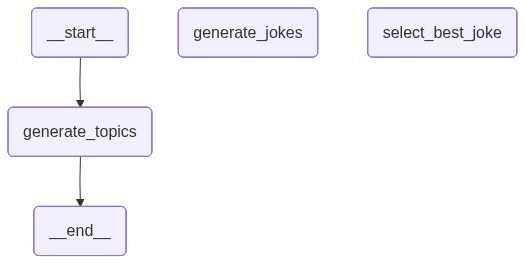

In [73]:
import operator
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import Annotated
from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from pydantic import SecretStr,Field
from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv
import os
from langgraph.types import Send


subject_prompt= """生成一个逗号分隔的列表，包含2个到5个与以下主题相关的例子：{topic}"""
jock_prompt= """请根据以下主题生成一个笑话：{topic}"""
best_jock_prompt= """以下是一些与{topic}相关的笑话，请从中选出最好的一个笑话ID"""





class Subjects(BaseMessage):
    subjects: list[str]


class Joke(BaseMessage):
    joke: str




class BestJock(BaseMessage):
    jock_id: int=Field(description="最佳笑话ID",ge=0)




model = ChatDeepSeek(
    model="deepseek-v4-pro", 
    api_key=SecretStr(os.getenv("DEEPSEEK_API_KEY") or ""),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)

class OverallState(TypedDict):
    topic: str
    subjects: list[str]
    jokes:Annotated[list, operator.add]
    best_joke:str


class JokeState(TypedDict):
    subjects: list[str]



def generate_topics(state:OverallState, config: RunnableConfig):
    prompt = subject_prompt.format(topic=state['topic'])
    response = model.with_structured_output(Subjects).invoke([HumanMessage(content=prompt)])
    return {"subjects": response.subjects}



def generate_jokes(state:JokeState, config: RunnableConfig):
    jokes = []
    for subject in state['subjects']:
        prompt = jock_prompt.format(topic=subject)
        response = model.with_structured_output(Joke).invoke([HumanMessage(content=prompt)])
        jokes.append(response.joke)
    return {"jokes": jokes}




def continue_to_jokes(state:OverallState, config: RunnableConfig):
    return [Send("generate_jokes",{"subjects":s})for s in state['subjects']]



def select_best_joke(state:OverallState, config: RunnableConfig):
    prompt = best_jock_prompt.format(topic=state['topic'])
    # 这里我们假设模型返回的是一个整数，表示最佳笑话的ID
    response = model.with_structured_output(BestJock).invoke([HumanMessage(content=prompt)])
    best_joke_id = response.jock_id
    if 0 <= best_joke_id < len(state['jokes']):
        return {"best_joke": state['jokes'][best_joke_id]}
    else:
        return {"best_joke": "无效的笑话ID"}
    




graph_builder = StateGraph(OverallState)
graph_builder.add_node("generate_topics", generate_topics)
graph_builder.add_node("generate_jokes", generate_jokes)
graph_builder.add_node("select_best_joke", select_best_joke)

graph_builder.add_edge(START, "generate_topics")

# 修改这一行：将 add_edge 改为 add_conditional_edges
graph_builder.add_conditional_edges("generate_topics", continue_to_jokes)

graph_builder.add_edge("generate_jokes", "select_best_joke")
graph_builder.add_edge("select_best_joke", END)

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

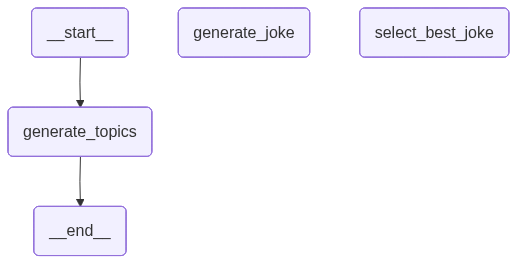

{'generate_topics': {'subjects': ['动物']}}
{'generate_joke': {'jokes': ['一只鸭子走进药店，问店员："有葡萄吗？"店员说："没有。"第二天鸭子又来了："有葡萄吗？"店员说："没有！"第三天鸭子又来了："有葡萄吗？"店员生气地说："没有！你要是再问，我就把你的脚钉在地板上！"第四天鸭子来了："有钉子吗？"店员说："没有。"鸭子说："那有葡萄吗？"']}}
{'select_best_joke': {'best_joke': '一只鸭子走进药店，问店员："有葡萄吗？"店员说："没有。"第二天鸭子又来了："有葡萄吗？"店员说："没有！"第三天鸭子又来了："有葡萄吗？"店员生气地说："没有！你要是再问，我就把你的脚钉在地板上！"第四天鸭子来了："有钉子吗？"店员说："没有。"鸭子说："那有葡萄吗？"'}}


In [ ]:
import operator
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import Annotated, List
from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from pydantic import SecretStr, BaseModel, Field
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv
import os
from langgraph.types import Send

load_dotenv()

# ---------- 定义结构化输出的 Pydantic 模型 ----------
class Subjects(BaseModel):
    subjects: List[str]

class Joke(BaseModel):
    joke: str

class BestJokeSelection(BaseModel):
    best_joke_id: int = Field(description="最佳笑话的索引（从0开始）")

# ---------- 模型初始化 ----------
model = ChatDeepSeek(
    model="deepseek-chat",
    api_key=SecretStr(os.getenv("DEEPSEEK_API_KEY") or ""),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)

# ---------- 状态定义 ----------
class OverallState(TypedDict):
    topic: str
    subjects: List[str]
    jokes: Annotated[List[str], operator.add]   # 每个笑话字符串会被累加
    best_joke: str

class JokeWorkerState(TypedDict):
    subject: str      # 单个主题，不是列表

# ---------- 节点函数 ----------
def generate_topics(state: OverallState, config: RunnableConfig):
    prompt = f"生成一个逗号分隔的列表，包含2个到5个与以下主题相关的例子，例如topic为颜色，那你可以生成红色，黄色，紫色等相关颜色的笑话，而不是说只生成颜色的笑话：{state['topic']}"
    response = model.with_structured_output(Subjects).invoke([HumanMessage(content=prompt)])
    return {"subjects": response.subjects}

def generate_joke(state: JokeWorkerState, config: RunnableConfig):
    """为单个主题生成一个笑话"""
    prompt = f"请根据以下主题生成一个笑话：{state['subject']}"
    response = model.with_structured_output(Joke).invoke([HumanMessage(content=prompt)])
    return {"jokes": [response.joke]}   # 返回列表以便 operator.add 连接

def continue_to_jokes(state: OverallState, config: RunnableConfig):
    """为每个主题创建一个并行任务"""
    return [Send("generate_joke", {"subject": s}) for s in state['subjects']]

def select_best_joke(state: OverallState, config: RunnableConfig):
    """根据所有生成的笑话，选出最佳的一个"""
    # 构建包含笑话列表的提示
    jokes_text = "\n".join([f"[{i}]: {joke}" for i, joke in enumerate(state['jokes'])])
    prompt = f"""以下是与"{state['topic']}"相关的2-5个笑话，请选出最好的一个，返回它的编号（从0开始）。

笑话列表：
{jokes_text}

请只返回编号。"""
    response = model.with_structured_output(BestJokeSelection).invoke([HumanMessage(content=prompt)])
    best_id = response.best_joke_id
    if 0 <= best_id < len(state['jokes']):
        return {"best_joke": state['jokes'][best_id]}
    else:
        return {"best_joke": "无有效笑话"}

# ---------- 图构建 ----------
graph_builder = StateGraph(OverallState)
graph_builder.add_node("generate_topics", generate_topics)
graph_builder.add_node("generate_joke", generate_joke)      # 注意节点名改为单数
graph_builder.add_node("select_best_joke", select_best_joke)

graph_builder.add_edge(START, "generate_topics")
graph_builder.add_conditional_edges("generate_topics", continue_to_jokes)
graph_builder.add_edge("generate_joke", "select_best_joke")
graph_builder.add_edge("select_best_joke", END)

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))



# 可选：显示图结构
# from IPython.display import Image
# display(Image(graph.get_graph().draw_mermaid_png()))


for s in graph.stream(
    {"topic": "颜色"},
):
    print(s)


In [77]:
for s in graph.stream(
    {"topic": "动物"}
):
    print(s)


BadRequestError: Error code: 400 - {'error': {'message': 'deepseek-reasoner does not support this tool_choice', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}